<a href="https://colab.research.google.com/github/manishkshtriya333-arch/Deep-Learning-Assignment2/blob/main/deep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 82.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 29.9MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 101MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.71MB/s]


Train: 60000 | Test: 10000


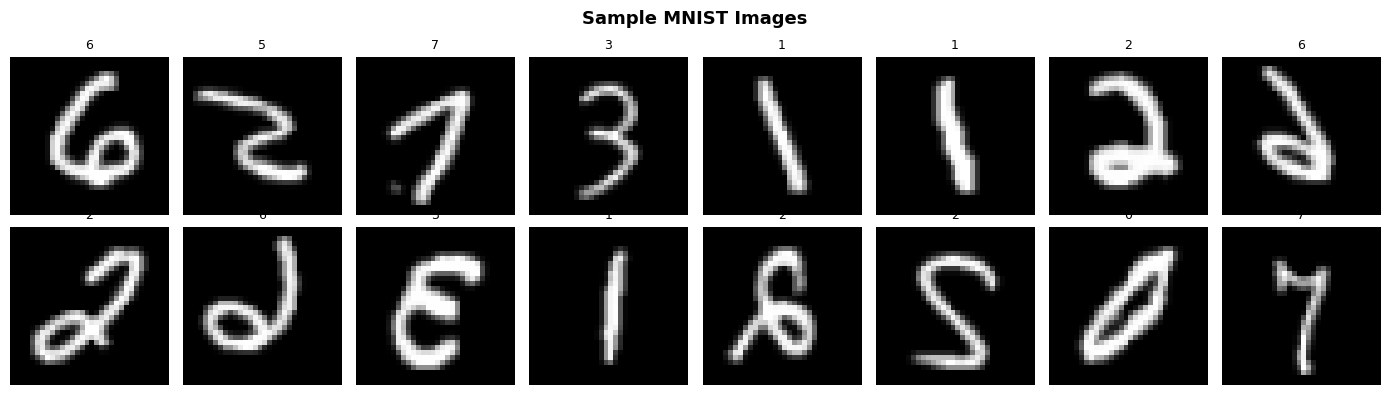

CustomCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
Total Parameters: 1,070,410
Epoch [1/10] Loss: 0.2650 | Train: 91.52% | Val: 96.73%
Epoch [2/10] Loss: 0.1259 | Train: 96.16% | Val: 98.19%
Epoch [3/10] Loss: 0.

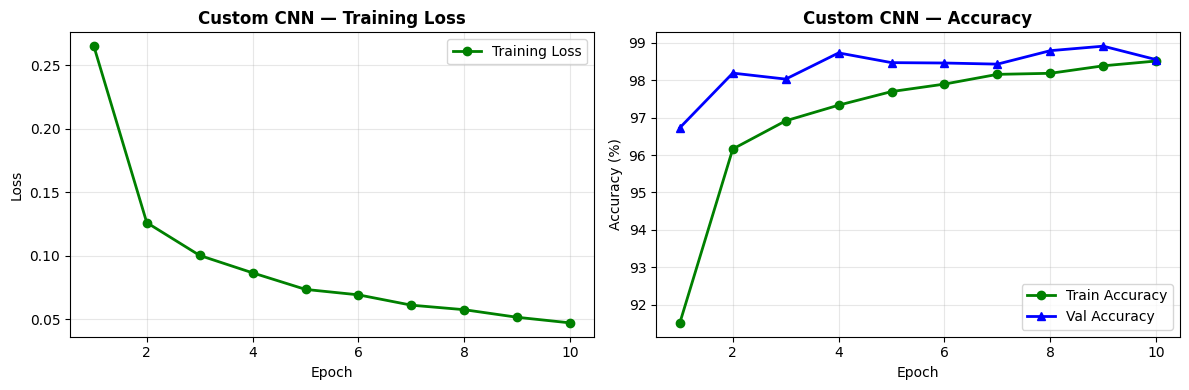

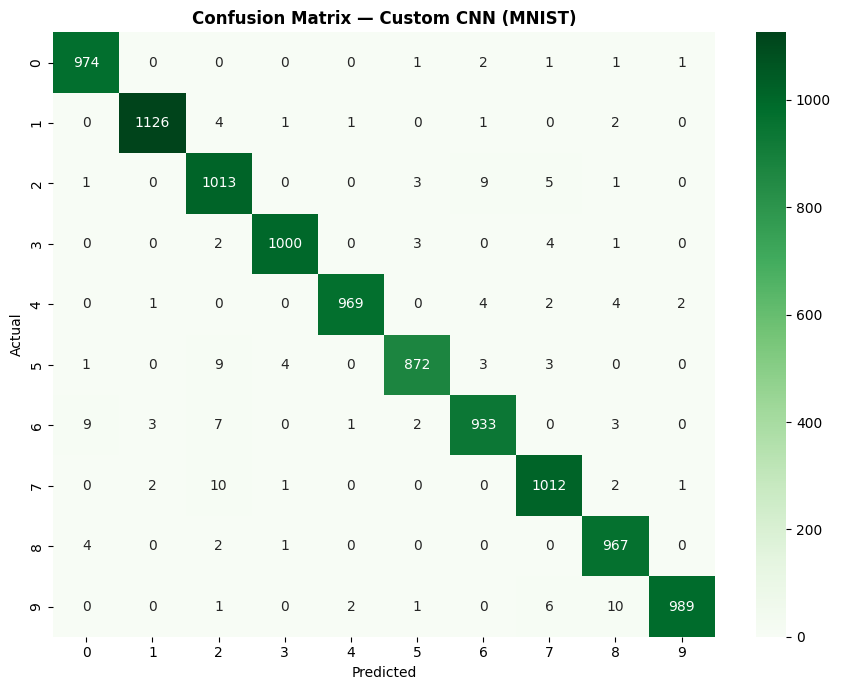

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.98      0.98       892
           6       0.98      0.97      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.99      0.98       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


Trainable Params: 8,266


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ── Device ───────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ── Load MNIST ───────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform_train)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

classes = [str(i) for i in range(10)]
print(f'Train: {len(train_dataset)} | Test: {len(test_dataset)}')

# ── Visualise Samples ─────────────────────────────────────────
dataiter = iter(train_loader)
images, labels = next(dataiter)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    img = (img * 0.5) + 0.5
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{labels[i].item()}', fontsize=9)
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Custom CNN Model ──────────────────────────────────────────
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)      # 32x32 -> 16x16
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)      # 16x16 -> 8x8
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x

model_cnn = CustomCNN().to(device)
print(model_cnn)
print(f'Total Parameters: {sum(p.numel() for p in model_cnn.parameters()):,}')

# ── Train Custom CNN ──────────────────────────────────────────
criterion    = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)

NUM_EPOCHS = 10
cnn_train_loss, cnn_train_acc, cnn_val_acc = [], [], []

for epoch in range(NUM_EPOCHS):
    model_cnn.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_cnn.zero_grad()
        outputs = model_cnn(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer_cnn.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total

    model_cnn.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_cnn(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)
    val_acc = 100. * val_correct / val_total

    cnn_train_loss.append(train_loss)
    cnn_train_acc.append(train_acc)
    cnn_val_acc.append(val_acc)
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%')

print(f'\nFinal CNN Test Accuracy: {cnn_val_acc[-1]:.2f}%')

# ── CNN Training Plots ────────────────────────────────────────
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, cnn_train_loss, 'g-o', linewidth=2, label='Training Loss')
axes[0].set_title('Custom CNN — Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, cnn_train_acc, 'g-o', linewidth=2, label='Train Accuracy')
axes[1].plot(epochs_range, cnn_val_acc,   'b-^', linewidth=2, label='Val Accuracy')
axes[1].set_title('Custom CNN — Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Confusion Matrix ──────────────────────────────────────────
model_cnn.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_cnn(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix — Custom CNN (MNIST)', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()
print(classification_report(all_labels, all_preds, target_names=classes))

# ── ResNet18 Transfer Learning ────────────────────────────────
model_resnet = models.resnet18(pretrained=True)
model_resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

for param in model_resnet.parameters():
    param.requires_grad = False

model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 10)
for param in model_resnet.fc.parameters():
    param.requires_grad = True
for param in model_resnet.conv1.parameters():
    param.requires_grad = True

model_resnet = model_resnet.to(device)
print(f'Trainable Params: {sum(p.numel() for p in model_resnet.parameters() if p.requires_grad):,}')

# ── Train ResNet18 ────────────────────────────────────────────
optimizer_resnet = optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()), lr=0.001)

RESNET_EPOCHS = 5
resnet_train_loss, resnet_val_acc = [], []

for epoch in range(RESNET_EPOCHS):
    model_resnet.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_resnet.zero_grad()
        outputs = model_resnet(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)

    model_resnet.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)
    val_acc = 100. * val_correct / val_total

    resnet_train_loss.append(train_loss)
    resnet_val_acc.append(val_acc)
    print(f'Epoch [{epoch+1}/{RESNET_EPOCHS}] Loss: {train_loss:.4f} | Val: {val_acc:.2f}%')

print(f'\nFinal ResNet18 Test Accuracy: {resnet_val_acc[-1]:.2f}%')

# ── CNN vs ResNet18 Bar Chart ─────────────────────────────────
plt.figure(figsize=(6, 4))
bars = plt.bar(['Custom CNN', 'ResNet18'],
               [cnn_val_acc[-1], resnet_val_acc[-1]],
               color=['#2d6a4f', '#52b788'], width=0.4, edgecolor='white')
plt.ylim([80, 100])
plt.ylabel('Test Accuracy (%)')
plt.title('CNN vs ResNet18 — MNIST', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{bar.get_height():.2f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()


# ============================================================
#  PART B — SENTIMENT CLASSIFICATION (IMDB)
#  RNN vs LSTM vs GRU
# ============================================================

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow: {tf.__version__}')

# ── Load IMDB ─────────────────────────────────────────────────
VOCAB_SIZE   = 10000
MAX_LEN      = 200
EMBED_DIM    = 128
HIDDEN_UNITS = 128
BATCH_SIZE   = 64
EPOCHS       = 5

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# ── Model Builder ─────────────────────────────────────────────
def build_model(model_type):
    model = Sequential(name=model_type)
    model.add(Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN))
    if model_type == 'RNN':
        model.add(SimpleRNN(HIDDEN_UNITS))
    elif model_type == 'LSTM':
        model.add(LSTM(HIDDEN_UNITS))
    elif model_type == 'GRU':
        model.add(GRU(HIDDEN_UNITS))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# ── Train Simple RNN ──────────────────────────────────────────
print('\n--- Training Simple RNN ---')
model_rnn = build_model('RNN')
model_rnn.summary()
history_rnn = model_rnn.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                             validation_data=(X_test, y_test), callbacks=[early_stop], verbose=1)
rnn_loss, rnn_acc = model_rnn.evaluate(X_test, y_test, verbose=0)
print(f'Simple RNN — Accuracy: {rnn_acc*100:.2f}% | Loss: {rnn_loss:.4f}')

# ── Train LSTM ────────────────────────────────────────────────
print('\n--- Training LSTM ---')
model_lstm = build_model('LSTM')
model_lstm.summary()
history_lstm = model_lstm.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                               validation_data=(X_test, y_test), callbacks=[early_stop], verbose=1)
lstm_loss, lstm_acc = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f'LSTM — Accuracy: {lstm_acc*100:.2f}% | Loss: {lstm_loss:.4f}')

# ── Train GRU ─────────────────────────────────────────────────
print('\n--- Training GRU ---')
model_gru = build_model('GRU')
model_gru.summary()
history_gru = model_gru.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                             validation_data=(X_test, y_test), callbacks=[early_stop], verbose=1)
gru_loss, gru_acc = model_gru.evaluate(X_test, y_test, verbose=0)
print(f'GRU — Accuracy: {gru_acc*100:.2f}% | Loss: {gru_loss:.4f}')

# ── Validation Plots ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_rnn.history['val_accuracy'],  'r-o', label='Simple RNN', linewidth=2)
axes[0].plot(history_lstm.history['val_accuracy'], 'g-s', label='LSTM',       linewidth=2)
axes[0].plot(history_gru.history['val_accuracy'],  'b-^', label='GRU',        linewidth=2)
axes[0].set_title('Validation Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_rnn.history['val_loss'],  'r-o', label='Simple RNN', linewidth=2)
axes[1].plot(history_lstm.history['val_loss'], 'g-s', label='LSTM',       linewidth=2)
axes[1].plot(history_gru.history['val_loss'],  'b-^', label='GRU',        linewidth=2)
axes[1].set_title('Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── Final Summary ─────────────────────────────────────────────
print('='*50)
print('        FINAL RESULTS SUMMARY')
print('='*50)
print(f'  PART A — MNIST Classification')
print(f'  Custom CNN  : {cnn_val_acc[-1]:.2f}%')
print(f'  ResNet18    : {resnet_val_acc[-1]:.2f}%')
print('-'*50)
print(f'  PART B — IMDB Sentiment Classification')
print(f'  Simple RNN  : {rnn_acc*100:.2f}%')
print(f'  LSTM        : {lstm_acc*100:.2f}%')
print(f'  GRU         : {gru_acc*100:.2f}%')
print('='*50)

# ── Overall Bar Chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
model_names = ['Custom CNN', 'ResNet18', 'Simple RNN', 'LSTM', 'GRU']
accuracies  = [cnn_val_acc[-1], resnet_val_acc[-1],
               rnn_acc*100, lstm_acc*100, gru_acc*100]
colors = ['#2d6a4f', '#52b788', '#e76f51', '#e76f51', '#e76f51']
bars = ax.bar(model_names, accuracies, color=colors, width=0.5, edgecolor='white')
ax.set_ylim([70, 102])
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Overall Model Accuracy Comparison', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Test Custom Sentiment ─────────────────────────────────────
word_index = imdb.get_word_index()

def predict_sentiment(review, model):
    words = review.lower().split()
    seq   = [word_index.get(w, 2) + 3 for w in words]
    seq   = pad_sequences([seq], maxlen=MAX_LEN, padding='post', truncating='post')
    pred  = model.predict(seq, verbose=0)[0][0]
    label = 'POSITIVE 😊' if pred > 0.5 else 'NEGATIVE 😞'
    print(f'Review   : "{review}"')
    print(f'Sentiment: {label} (score: {pred:.2f})\n')

predict_sentiment("This movie was absolutely fantastic and brilliant", model_gru)
predict_sentiment("The film was boring and a complete waste of time", model_gru)
predict_sentiment("An average movie with some good moments", model_gru)